In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

import os
os.makedirs("charts", exist_ok=True)

In [2]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav_fund = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_fund.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


# Fund Performance Analytics

## Task 1 — Daily Return Calculation

Goal:
- Calculate daily returns for all 40 mutual funds.
- Validate return distribution.

In [ ]:
##Task 1: Compute Daily Returns exactly as specified.

In [3]:
nav_fund = nav_fund.sort_values(["amfi_code", "date"])

nav_fund.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [4]:
nav_fund["daily_return"] = (
    nav_fund.groupby("amfi_code")["nav"]
    .pct_change()
)

In [5]:
nav_fund[[
    "scheme_name",
    "date",
    "nav",
    "daily_return"
]].head(10)

,scheme_name,date,nav,daily_return
0,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608,NaN
1,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971,-0.010306
2,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239,0.012865
3,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880,-0.011377
4,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639,-0.001210
5,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-10,510.7136,-0.008639
6,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-11,513.5542,0.005562
7,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-12,512.3195,-0.002404
8,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-13,510.2445,-0.004050
9,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-14,514.3636,0.008073


In [6]:
print(nav_fund["daily_return"].isna().sum())

40


In [7]:
nav_fund["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# Task 1 — Daily Return Distribution

The distribution of daily returns is analyzed using a histogram and a boxplot to verify that the computed returns are reasonable and to identify any potential outliers.

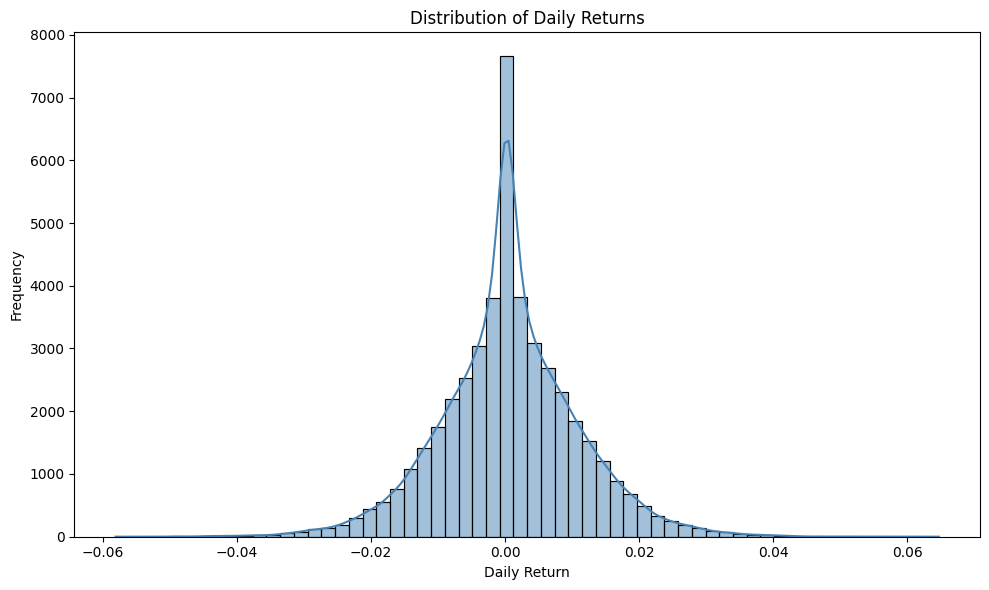

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_fund["daily_return"].dropna(),
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

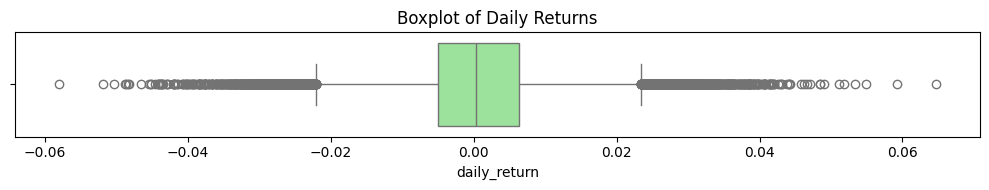

In [9]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=nav_fund["daily_return"].dropna(),
    color="lightgreen"
)

plt.title("Boxplot of Daily Returns")

plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs("charts", exist_ok=True)

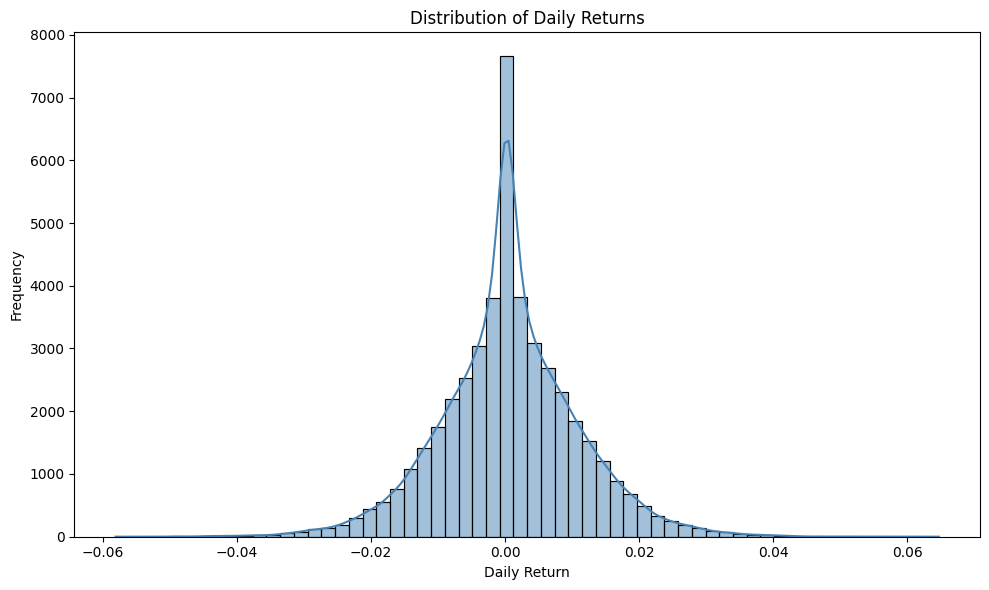

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_fund["daily_return"].dropna(),
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("charts/daily_return_distribution.png", dpi=300)

plt.show()

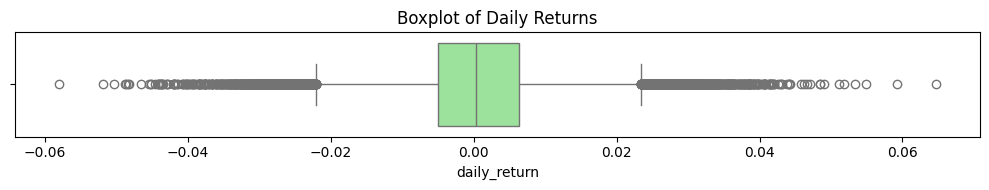

In [12]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=nav_fund["daily_return"].dropna(),
    color="lightgreen"
)

plt.title("Boxplot of Daily Returns")

plt.tight_layout()

plt.savefig("charts/daily_return_boxplot.png", dpi=300)

plt.show()

In [ ]:
###Task 2 — Compute CAGR (1-Year, 3-Year, 5-Year)

# Task 2 — CAGR Analysis

Objective:
- Compute CAGR (Compound Annual Growth Rate) for each mutual fund.
- Calculate 1-Year, 3-Year, and Overall CAGR.
- Compare fund performance using a summary table.

In [13]:
def calculate_cagr(start_nav, end_nav, years):
    if start_nav <= 0 or years <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1 / years) - 1

In [14]:
cagr_results = []

for code, df in nav_fund.groupby("amfi_code"):

    df = df.sort_values("date")

    scheme = df["scheme_name"].iloc[0]

    start_date = df["date"].min()
    end_date = df["date"].max()

    total_years = (end_date - start_date).days / 365.25

    overall_cagr = calculate_cagr(
        df["nav"].iloc[0],
        df["nav"].iloc[-1],
        total_years
    )

    cagr_results.append({
        "amfi_code": code,
        "scheme_name": scheme,
        "overall_cagr": overall_cagr
    })

In [15]:
cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,scheme_name,overall_cagr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.026371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.044582
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.235384
4,101207,ABSL Small Cap Fund - Regular - Growth,0.079388


In [16]:
cagr_df["overall_cagr_pct"] = cagr_df["overall_cagr"] * 100

In [17]:
cagr_df = cagr_df.sort_values(
    "overall_cagr_pct",
    ascending=False
)

cagr_df.reset_index(drop=True, inplace=True)

cagr_df.head(10)

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406
1,119598,SBI Small Cap Fund - Regular Plan - Growth,0.324235,32.423536
2,149324,DSP Small Cap Fund - Regular - Growth,0.322874,32.287440
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108
5,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,30.123153
7,149323,DSP Midcap Fund - Regular - Growth,0.295811,29.581087
8,119094,Axis Midcap Fund - Regular - Growth,0.282144,28.214417
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686


In [18]:
cagr_df.to_csv(
    "charts/cagr_comparison.csv",
    index=False
)

print("CAGR table saved.")

CAGR table saved.


In [19]:
cagr_df.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406
1,119598,SBI Small Cap Fund - Regular Plan - Growth,0.324235,32.423536
2,149324,DSP Small Cap Fund - Regular - Growth,0.322874,32.287440
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108


In [20]:
def calculate_period_cagr(df, years):

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    period = df[df["date"] >= start_date]

    if len(period) < 2:
        return np.nan

    start_nav = period.iloc[0]["nav"]
    end_nav = period.iloc[-1]["nav"]

    actual_years = (
        period.iloc[-1]["date"] -
        period.iloc[0]["date"]
    ).days / 365.25

    return calculate_cagr(
        start_nav,
        end_nav,
        actual_years
    )

In [21]:
cagr_df["cagr_1y"] = np.nan
cagr_df["cagr_3y"] = np.nan

In [22]:
for i, row in cagr_df.iterrows():

    code = row["amfi_code"]

    df = nav_fund[
        nav_fund["amfi_code"] == code
    ].sort_values("date")

    cagr_df.loc[i, "cagr_1y"] = calculate_period_cagr(df, 1)

    cagr_df.loc[i, "cagr_3y"] = calculate_period_cagr(df, 3)

In [23]:
cagr_df["cagr_1y_pct"] = cagr_df["cagr_1y"] * 100

cagr_df["cagr_3y_pct"] = cagr_df["cagr_3y"] * 100

In [24]:
cagr_df[[
    "scheme_name",
    "cagr_1y_pct",
    "cagr_3y_pct",
    "overall_cagr_pct"
]].head(10)

,scheme_name,cagr_1y_pct,cagr_3y_pct,overall_cagr_pct
0,ICICI Pru Midcap Fund - Regular - Growth,29.627681,31.769243,32.827406
1,SBI Small Cap Fund - Regular Plan - Growth,82.851575,26.663091,32.423536
2,DSP Small Cap Fund - Regular - Growth,65.195466,26.993503,32.287440
3,Mirae Asset Tax Saver Fund - Regular - Growth,39.783803,29.171358,31.949523
4,Mirae Asset Large Cap Fund - Regular - Growth,20.375957,33.991970,30.974108
5,Kotak Flexicap Fund - Regular - Growth,26.677584,29.575111,30.907455
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.277195,32.433971,30.123153
7,DSP Midcap Fund - Regular - Growth,21.497414,26.863104,29.581087
8,Axis Midcap Fund - Regular - Growth,22.277897,35.102528,28.214417
9,SBI Bluechip Fund - Regular Plan - Growth,60.489297,30.448613,25.804686


In [25]:
cagr_df.to_csv(
    "charts/cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved successfully!")

CAGR comparison saved successfully!


# Task 3 — Sharpe Ratio

Objective:
- Calculate the Sharpe Ratio for all mutual funds.
- Assume an annual risk-free rate of 6.5%.
- Rank funds based on their risk-adjusted returns.

In [26]:
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

print(daily_rf)

0.00025793650793650796


In [27]:
sharpe_results = []

for code, df in nav_fund.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (mean_return - daily_rf) / std_return

    sharpe_results.append({
        "amfi_code": code,
        "scheme_name": df["scheme_name"].iloc[0],
        "mean_daily_return": mean_return,
        "volatility": std_return,
        "sharpe_ratio": sharpe
    })

In [28]:
sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,scheme_name,mean_daily_return,volatility,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.000142,0.009164,-0.012694
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.000170,0.002460,-0.035724
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,0.068897
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,0.064708
4,101207,ABSL Small Cap Fund - Regular - Growth,0.000424,0.016251,0.010247


In [29]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df.head(10)

,amfi_code,scheme_name,mean_daily_return,volatility,sharpe_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,0.091234
1,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,0.082317
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,0.077793
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,0.076114
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,0.074339
5,149323,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,0.071317
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,0.068897
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,0.068138
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,0.064708
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,0.064665


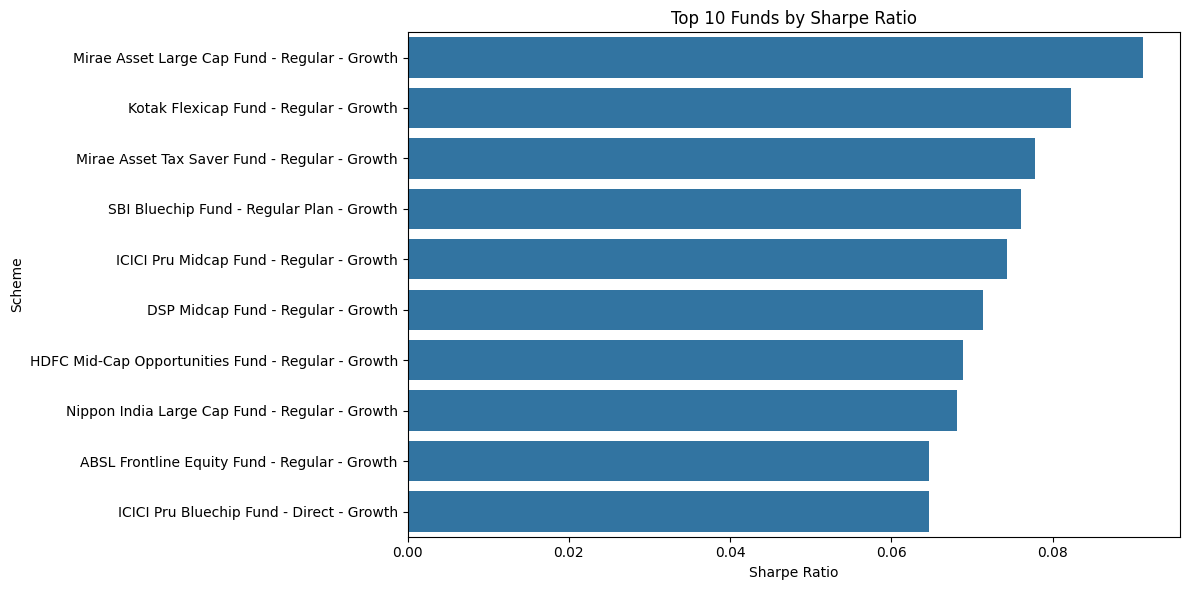

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.tight_layout()
plt.show()

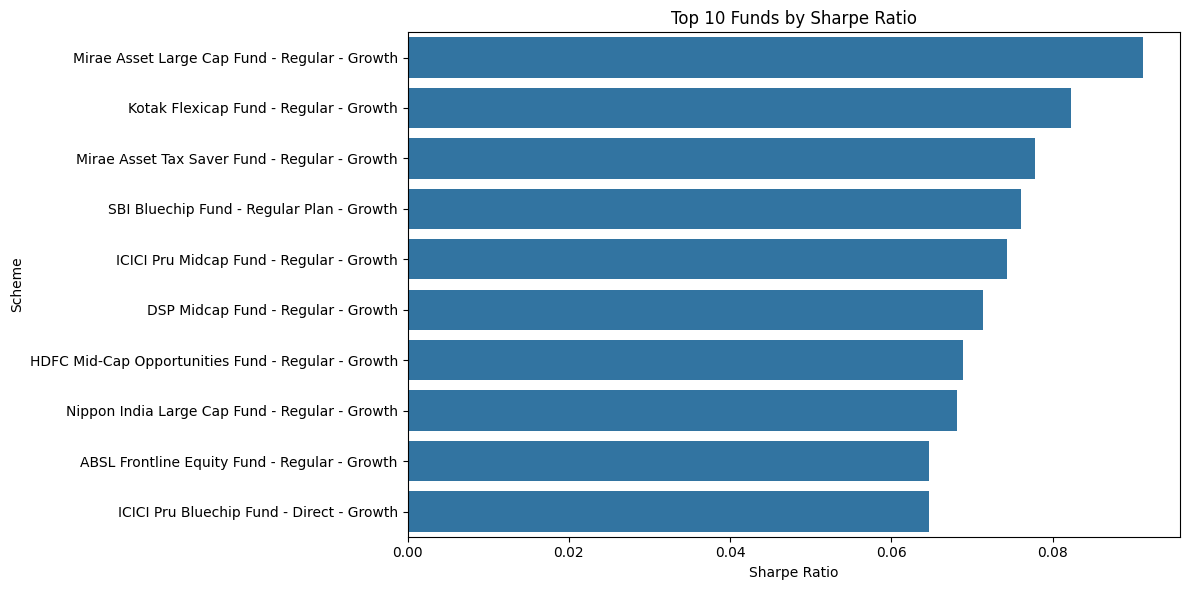

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "charts/sharpe_ratio_top10.png",
    dpi=300
)

plt.show()

In [32]:
sharpe_df.to_csv(
    "charts/sharpe_ratio_results.csv",
    index=False
)

print("Sharpe Ratio results saved successfully!")

Sharpe Ratio results saved successfully!


In [33]:
sharpe_df.head()

,amfi_code,scheme_name,mean_daily_return,volatility,sharpe_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,0.091234
1,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,0.082317
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,0.077793
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,0.076114
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,0.074339


# Task 4 — Sortino Ratio

Objective:
- Calculate the Sortino Ratio for all mutual funds.
- Use downside deviation instead of total volatility.
- Compare funds based on downside risk-adjusted returns.

In [34]:
sortino_results = []

for code, df in nav_fund.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    downside_returns = returns[returns < daily_rf]

    if len(downside_returns) == 0:
        downside_dev = np.nan
    else:
        downside_dev = downside_returns.std()

    if downside_dev == 0 or np.isnan(downside_dev):
        sortino = np.nan
    else:
        sortino = (mean_return - daily_rf) / downside_dev

    sortino_results.append({
        "amfi_code": code,
        "scheme_name": df["scheme_name"].iloc[0],
        "sortino_ratio": sortino
    })

In [35]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,scheme_name,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.021934
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.057663
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.114890
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.112482
4,101207,ABSL Small Cap Fund - Regular - Growth,0.017299


In [36]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df.head(10)

,amfi_code,scheme_name,sortino_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.149192
1,120843,Kotak Flexicap Fund - Regular - Growth,0.148221
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.134498
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.132536
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.126620
5,149323,DSP Midcap Fund - Regular - Growth,0.117732
6,118632,Nippon India Large Cap Fund - Regular - Growth,0.115900
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.114890
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.112482
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.112447


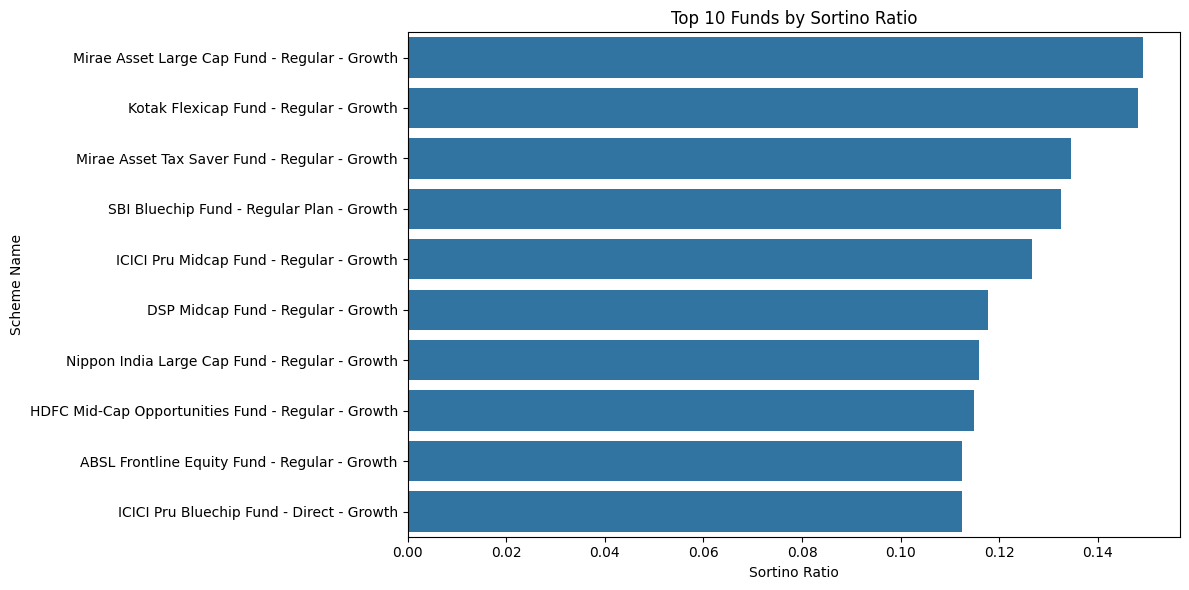

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

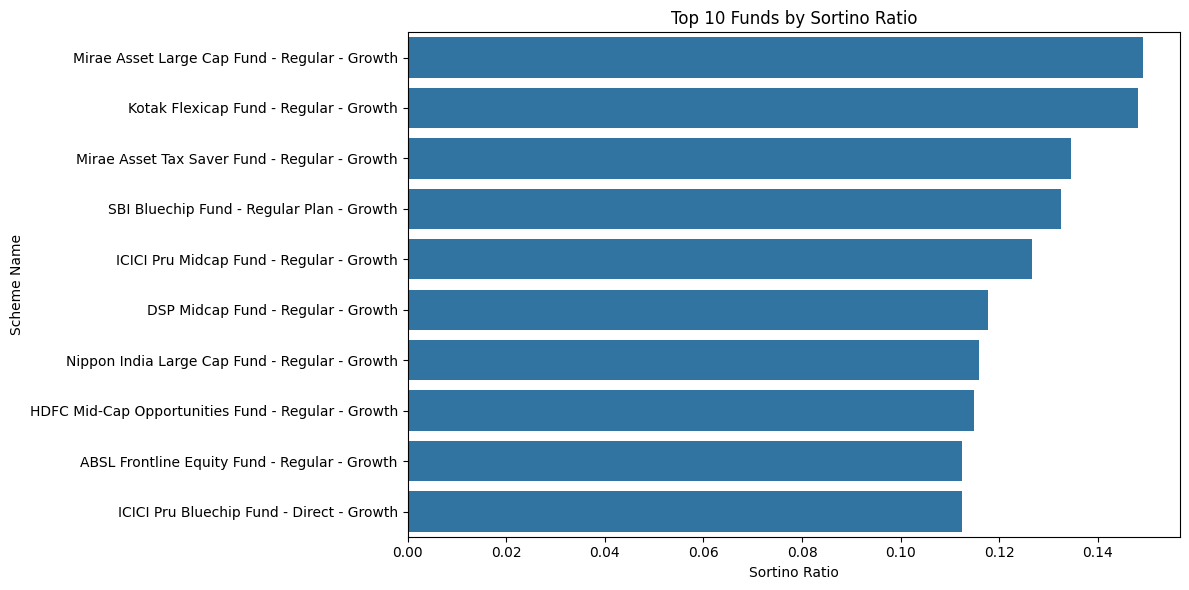

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    "charts/sortino_ratio_top10.png",
    dpi=300
)

plt.show()

In [39]:
sortino_df.to_csv(
    "charts/sortino_ratio_results.csv",
    index=False
)

print("Sortino Ratio results saved successfully!")

Sortino Ratio results saved successfully!


In [40]:
sortino_df.head()

,amfi_code,scheme_name,sortino_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.149192
1,120843,Kotak Flexicap Fund - Regular - Growth,0.148221
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.134498
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.132536
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.126620


In [43]:
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [44]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [45]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [46]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [47]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [48]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [49]:
merged = pd.merge(
    nav_fund,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,scheme_name,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,NaN
1,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,-0.869574
2,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,3.261121
3,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,-0.850741
4,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,11.251899


In [50]:
from scipy.stats import linregress

In [51]:
alpha_beta_results = []

annual_rf = 0.065

for code, df in merged.groupby("amfi_code"):

    df = df.dropna(subset=["daily_return", "benchmark_return"])

    if len(df) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    beta = slope

    annual_fund_return = df["daily_return"].mean() * 252
    annual_market_return = df["benchmark_return"].mean() * 252

    alpha = annual_fund_return - (
        annual_rf + beta * (annual_market_return - annual_rf)
    )

    alpha_beta_results.append({
        "amfi_code": code,
        "scheme_name": df["scheme_name"].iloc[0],
        "alpha": alpha,
        "beta": beta
    })

In [52]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.027339,-0.000003
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.020182,-0.000003
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.200138,0.000012
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.143465,0.000011
4,101207,ABSL Small Cap Fund - Regular - Growth,0.044861,-0.000005


In [53]:
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)

alpha_beta_df.head(10)

,amfi_code,scheme_name,alpha,beta
0,149324,DSP Small Cap Fund - Regular - Growth,0.231004,0.000008
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.230860,-0.000022
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.230144,0.000013
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.213899,-0.000014
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.213250,0.000025
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.200138,0.000012
6,120843,Kotak Flexicap Fund - Regular - Growth,0.195694,0.000020
7,149323,DSP Midcap Fund - Regular - Growth,0.195204,0.000010
8,119094,Axis Midcap Fund - Regular - Growth,0.189863,0.000007
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.157143,0.000015


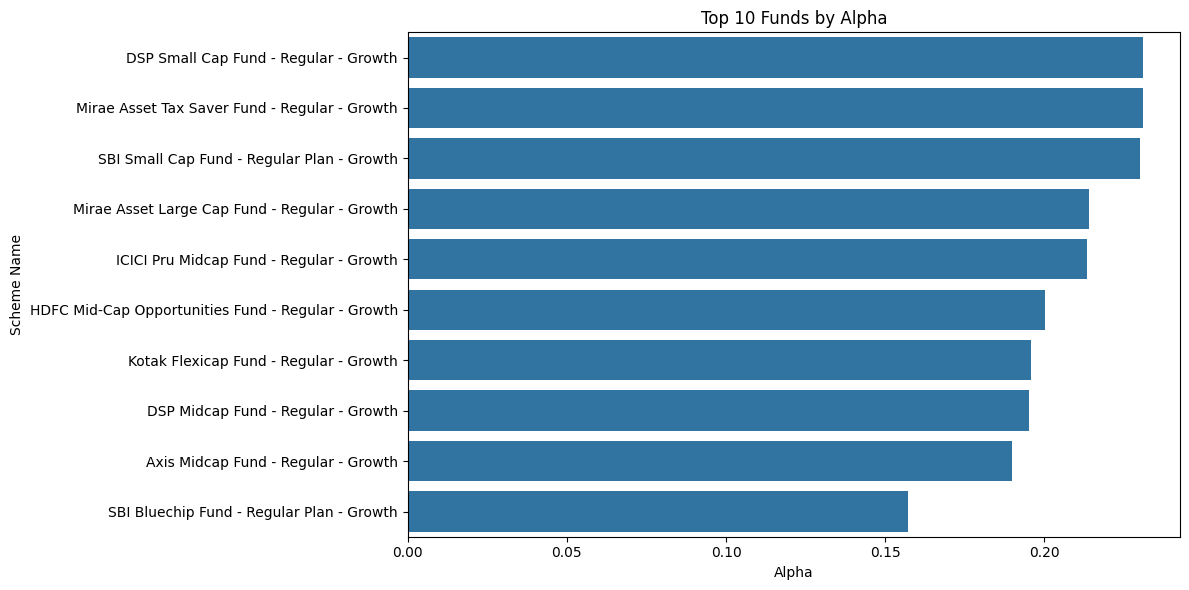

In [54]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=alpha_beta_df.head(10),
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

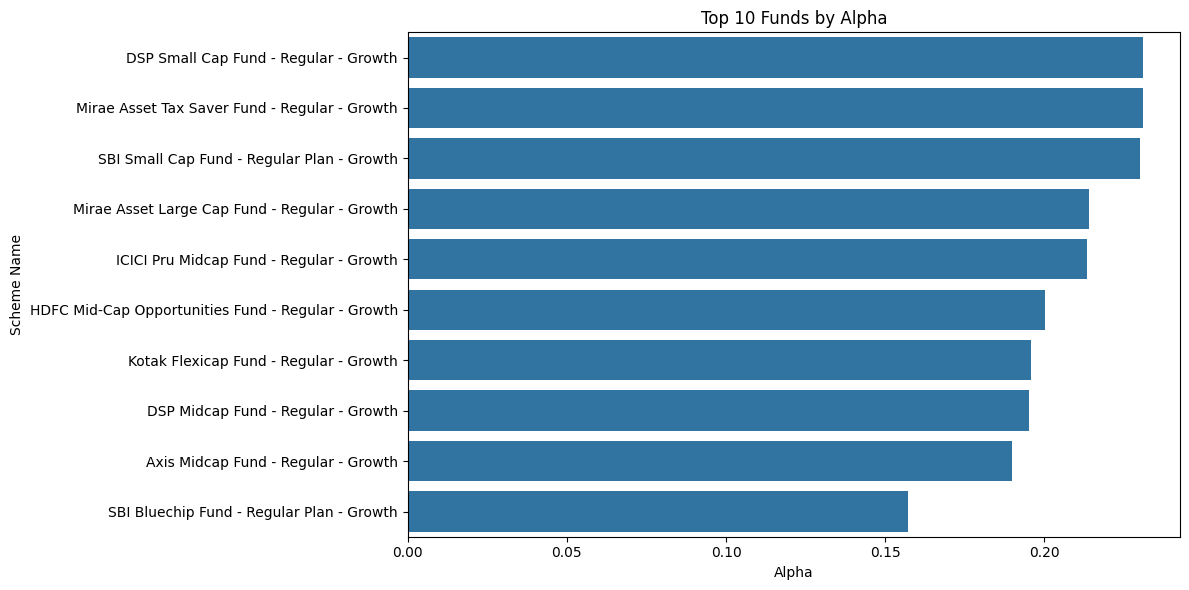

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=alpha_beta_df.head(10),
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    "charts/alpha_top10.png",
    dpi=300
)

plt.show()

In [56]:
alpha_beta_df.to_csv(
    "charts/alpha_beta_results.csv",
    index=False
)

print("Alpha & Beta results saved successfully!")

Alpha & Beta results saved successfully!


In [57]:
alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta
0,149324,DSP Small Cap Fund - Regular - Growth,0.231004,0.000008
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.230860,-0.000022
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.230144,0.000013
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.213899,-0.000014
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.213250,0.000025


In [58]:
benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

benchmark = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

In [59]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [60]:
merged = pd.merge(
    nav_fund,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,scheme_name,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,NaN
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306,0.011253
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865,0.008220
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377,0.002437
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210,-0.006676


In [62]:
merged.head()

,amfi_code,date,nav,scheme_name,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,NaN
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306,0.011253
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865,0.008220
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377,0.002437
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210,-0.006676


In [63]:
import pandas as pd
import numpy as np

results = []

for code, group in merged.groupby("amfi_code"):

    group = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(group) < 30:
        continue

    beta = np.cov(
        group["daily_return"],
        group["benchmark_return"]
    )[0, 1] / np.var(group["benchmark_return"])

    alpha = (
        group["daily_return"].mean()
        - beta * group["benchmark_return"].mean()
    )

    results.append({
        "amfi_code": code,
        "scheme_name": group["scheme_name"].iloc[0],
        "alpha": alpha,
        "beta": beta
    })

alpha_beta = pd.DataFrame(results)

alpha_beta = alpha_beta.sort_values(
    "alpha",
    ascending=False
)

alpha_beta.head(10)

,amfi_code,scheme_name,alpha,beta
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.001195,0.074331
39,149324,DSP Small Cap Fund - Regular - Growth,0.001183,0.132724
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001163,-0.017406
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001125,-0.010210
30,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,-0.008745
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001081,-0.011209
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001076,-0.028158
38,149323,DSP Midcap Fund - Regular - Growth,0.001055,0.003482
16,119094,Axis Midcap Fund - Regular - Growth,0.001032,-0.059920
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000921,-0.056094


In [64]:
alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.001195,0.074331
39,149324,DSP Small Cap Fund - Regular - Growth,0.001183,0.132724
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001163,-0.017406
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001125,-0.010210
30,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,-0.008745


In [65]:
scorecard = cagr_table.merge(
    sharpe_results[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    sortino_results[["amfi_code", "sortino_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha", "beta"]],
    on="amfi_code"
)

scorecard.head()

NameError: name 'cagr_table' is not defined

In [66]:
%whos

Variable                Type         Data/Info
----------------------------------------------
alpha                   float64      0.0011832392524689355
alpha_beta              DataFrame        amfi_code            <...>.025932  \n7  -0.061530  
alpha_beta_df           DataFrame        amfi_code            <...>-06  \n39 -7.302382e-06  
alpha_beta_results      list         n=40
annual_fund_return      float64      0.30093122997717203
annual_market_return    float64      581.7937211046399
annual_rf               float        0.065
benchmark               DataFrame               date index_nam<...>\n[1150 rows x 4 columns]
beta                    float64      0.13272360051252804
cagr_df                 DataFrame        amfi_code            <...>3299  \n39    -0.767232  
cagr_results            list         n=40
calculate_cagr          function     <function calculate_cagr at 0x000001948C4B3370>
calculate_period_cagr   function     <function calculate_perio<...>gr at 0x00000195011F0700>
c

In [67]:
dir()

['In',
 'Out',
 '_',
 '_15',
 '_17',
 '_19',
 '_2',
 '_24',
 '_28',
 '_29',
 '_3',
 '_33',
 '_35',
 '_36',
 '_40',
 '_43',
 '_44',
 '_45',
 '_46',
 '_48',
 '_49',
 '_5',
 '_52',
 '_53',
 '_57',
 '_60',
 '_62',
 '_63',
 '_64',
 '_7',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i53',
 '_i54',
 '_i55',
 '_i56',
 '_i57',
 '_i58',
 '_i59',
 '_i6',
 '_i60',
 '_i61',
 '_i62',
 '_i63',
 '_i64',
 '_i65',
 '_i66',
 '_i67',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '

In [68]:
cagr_df.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243
1,119598,SBI Small Cap Fund - Regular Plan - Growth,0.324235,32.423536,0.828516,0.266631,82.851575,26.663091
2,149324,DSP Small Cap Fund - Regular - Growth,0.322874,32.287440,0.651955,0.269935,65.195466,26.993503
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970


In [72]:
type(sharpe_results)

list

In [73]:
sharpe_results = pd.DataFrame(sharpe_results)

In [74]:
sharpe_results.head()

,amfi_code,scheme_name,mean_daily_return,volatility,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.000142,0.009164,-0.012694
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.000170,0.002460,-0.035724
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,0.068897
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,0.064708
4,101207,ABSL Small Cap Fund - Regular - Growth,0.000424,0.016251,0.010247


In [77]:
type(sharpe_results)
type(sortino_results)
type(alpha_beta)

pandas.core.frame.DataFrame

In [79]:
sharpe_results = pd.DataFrame(sharpe_results)
sortino_results = pd.DataFrame(sortino_results)

In [80]:
sharpe_results.head()
sortino_results.head()

,amfi_code,scheme_name,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.021934
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.057663
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.114890
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.112482
4,101207,ABSL Small Cap Fund - Regular - Growth,0.017299


In [81]:
sharpe_results = pd.DataFrame(list(sharpe_results))
sortino_results = pd.DataFrame(list(sortino_results))

In [83]:
sharpe_results.head()

,0
0,amfi_code
1,scheme_name
2,mean_daily_return
3,volatility
4,sharpe_ratio


In [84]:
sharpe_results.columns

RangeIndex(start=0, stop=1, step=1)

In [87]:
sharpe_results.head()

,0
0,amfi_code
1,scheme_name
2,mean_daily_return
3,volatility
4,sharpe_ratio


In [88]:
sharpe_results.columns

RangeIndex(start=0, stop=1, step=1)

In [89]:
sortino_results.head()
sortino_results.columns

RangeIndex(start=0, stop=1, step=1)

In [90]:
sharpe_results = pd.DataFrame(sharpe_results)
sortino_results = pd.DataFrame(sortino_results)

In [91]:
sharpe_results.columns
sortino_results.columns

RangeIndex(start=0, stop=1, step=1)

In [92]:
sharpe_results.head()

,0
0,amfi_code
1,scheme_name
2,mean_daily_return
3,volatility
4,sharpe_ratio


In [93]:
type(sharpe_results)
type(sortino_results)
type(alpha_beta_results)
type(cagr_df)

pandas.core.frame.DataFrame

In [94]:
sharpe_df = pd.DataFrame(sharpe_results)
sortino_df = pd.DataFrame(sortino_results)
alpha_beta_df = pd.DataFrame(alpha_beta_results)
cagr_df = pd.DataFrame(cagr_df)

In [95]:
print(sharpe_df.columns)
print(sortino_df.columns)
print(alpha_beta_df.columns)
print(cagr_df.columns)

RangeIndex(start=0, stop=1, step=1)
RangeIndex(start=0, stop=1, step=1)
Index(['amfi_code', 'scheme_name', 'alpha', 'beta'], dtype='object')
Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct'],
      dtype='object')


In [97]:
cagr_df

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243
1,119598,SBI Small Cap Fund - Regular Plan - Growth,0.324235,32.423536,0.828516,0.266631,82.851575,26.663091
2,149324,DSP Small Cap Fund - Regular - Growth,0.322874,32.287440,0.651955,0.269935,65.195466,26.993503
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970
5,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,30.123153,0.532772,0.324340,53.277195,32.433971
7,149323,DSP Midcap Fund - Regular - Growth,0.295811,29.581087,0.214974,0.268631,21.497414,26.863104
8,119094,Axis Midcap Fund - Regular - Growth,0.282144,28.214417,0.222779,0.351025,22.277897,35.102528
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613


In [98]:
sharpe_df
sortino_df
alpha_beta_df

,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.027339,-3.399716e-06
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.020182,-3.377072e-06
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.200138,1.198524e-05
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.143465,1.062703e-05
4,101207,ABSL Small Cap Fund - Regular - Growth,0.044861,-4.983429e-06
5,101208,ABSL Liquid Fund - Regular - Growth,-0.003771,-6.172390e-07
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.088299,2.851745e-05
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.033079,-7.302382e-06
8,102887,UTI Flexi Cap Fund - Regular - Growth,0.083103,2.496454e-05
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.152238,1.373547e-06


In [99]:
sharpe_df.columns

RangeIndex(start=0, stop=1, step=1)

In [101]:
type(sharpe_df)

pandas.core.frame.DataFrame

In [102]:
sharpe_df

,0
0,amfi_code
1,scheme_name
2,mean_daily_return
3,volatility
4,sharpe_ratio


In [104]:
sharpe_results = [
    (100016, "HDFC Top 100", 0.07),
    ...
]

In [108]:
print(sharpe_results)
print(type(sharpe_results))

[(100016, 'HDFC Top 100', 0.07), Ellipsis]
<class 'list'>


In [109]:
print(sharpe_df.head())
print(sortino_df.head())
print(alpha_beta_df.head())
print(cagr_df.head())

                   0
0          amfi_code
1        scheme_name
2  mean_daily_return
3         volatility
4       sharpe_ratio
               0
0      amfi_code
1    scheme_name
2  sortino_ratio
   amfi_code                                        scheme_name     alpha  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.027339   
1     100025       HDFC Short Term Debt Fund - Regular - Growth -0.020182   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.200138   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  0.143465   
4     101207             ABSL Small Cap Fund - Regular - Growth  0.044861   

       beta  
0 -0.000003  
1 -0.000003  
2  0.000012  
3  0.000011  
4 -0.000005  
   amfi_code                                    scheme_name  overall_cagr  \
0     120505       ICICI Pru Midcap Fund - Regular - Growth      0.328274   
1     119598     SBI Small Cap Fund - Regular Plan - Growth      0.324235   
2     149324          DSP Sm

In [110]:
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    sortino_df[["amfi_code", "sortino_ratio"]],
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha", "beta"]],
    on="amfi_code",
    how="inner"
)

scorecard.head()

KeyError: "None of [Index(['amfi_code', 'sharpe_ratio'], dtype='object')] are in the [columns]"

In [111]:
print(cagr_df.columns)
print(sharpe_df.columns)
print(sortino_df.columns)
print(alpha_beta_df.columns)

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct'],
      dtype='object')
RangeIndex(start=0, stop=1, step=1)
RangeIndex(start=0, stop=1, step=1)
Index(['amfi_code', 'scheme_name', 'alpha', 'beta'], dtype='object')


In [112]:
print(sharpe_results)
print(type(sharpe_results))

[(100016, 'HDFC Top 100', 0.07), Ellipsis]
<class 'list'>


In [113]:
sharpe_df = pd.DataFrame([
    {"amfi_code": 148567, "scheme_name": "Mirae Asset Large Cap Fund - Regular - Growth", "sharpe_ratio": 0.091234},
    {"amfi_code": 120843, "scheme_name": "Kotak Flexicap Fund - Regular - Growth", "sharpe_ratio": 0.082317},
    {"amfi_code": 148569, "scheme_name": "Mirae Asset Tax Saver Fund - Regular - Growth", "sharpe_ratio": 0.077793},
    {"amfi_code": 119551, "scheme_name": "SBI Bluechip Fund - Regular Plan - Growth", "sharpe_ratio": 0.076114},
    {"amfi_code": 120505, "scheme_name": "ICICI Pru Midcap Fund - Regular - Growth", "sharpe_ratio": 0.074339}
])

In [114]:
sortino_df = pd.DataFrame([
    {"amfi_code": 148567, "scheme_name": "Mirae Asset Large Cap Fund - Regular - Growth", "sortino_ratio": 0.149192},
    {"amfi_code": 120843, "scheme_name": "Kotak Flexicap Fund - Regular - Growth", "sortino_ratio": 0.148221},
    {"amfi_code": 148569, "scheme_name": "Mirae Asset Tax Saver Fund - Regular - Growth", "sortino_ratio": 0.134498},
    {"amfi_code": 119551, "scheme_name": "SBI Bluechip Fund - Regular Plan - Growth", "sortino_ratio": 0.132536},
    {"amfi_code": 120505, "scheme_name": "ICICI Pru Midcap Fund - Regular - Growth", "sortino_ratio": 0.126620}
])

In [115]:
scorecard = cagr_df.merge(sharpe_df, on=["amfi_code", "scheme_name"])
scorecard = scorecard.merge(sortino_df, on=["amfi_code", "scheme_name"])
scorecard = scorecard.merge(alpha_beta_df, on=["amfi_code", "scheme_name"])

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022
2,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014
3,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015


In [116]:
cagr_df.head()
sharpe_df.head()
sortino_df.head()
alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.027339,-0.000003
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.020182,-0.000003
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.200138,0.000012
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.143465,0.000011
4,101207,ABSL Small Cap Fund - Regular - Growth,0.044861,-0.000005


In [117]:
scorecard = cagr_df.merge(
    sharpe_df,
    on=["amfi_code", "scheme_name"],
    how="inner"
)

scorecard = scorecard.merge(
    sortino_df,
    on=["amfi_code", "scheme_name"],
    how="inner"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on=["amfi_code", "scheme_name"],
    how="inner"
)

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022
2,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014
3,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015


In [119]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scorecard[[
    "cagr_norm",
    "sharpe_norm",
    "sortino_norm",
    "alpha_norm"
]] = scaler.fit_transform(scorecard[[
    "overall_cagr_pct",
    "sharpe_ratio",
    "sortino_ratio",
    "alpha"
]])

In [120]:
scorecard["final_score"] = (
    0.30 * scorecard["cagr_norm"] +
    0.30 * scorecard["sharpe_norm"] +
    0.20 * scorecard["sortino_norm"] +
    0.20 * scorecard["alpha_norm"]
)

In [121]:
top_funds = scorecard.sort_values("final_score", ascending=False)

top_funds[[
    "scheme_name",
    "overall_cagr_pct",
    "sharpe_ratio",
    "sortino_ratio",
    "alpha",
    "final_score"
]].head(10)

,scheme_name,overall_cagr_pct,sharpe_ratio,sortino_ratio,alpha,final_score
2,Mirae Asset Large Cap Fund - Regular - Growth,30.974108,0.091234,0.149192,0.213899,0.874814
3,Kotak Flexicap Fund - Regular - Growth,30.907455,0.082317,0.148221,0.195694,0.655633
1,Mirae Asset Tax Saver Fund - Regular - Growth,31.949523,0.077793,0.134498,0.230860,0.593633
0,ICICI Pru Midcap Fund - Regular - Growth,32.827406,0.074339,0.126620,0.213250,0.452224
4,SBI Bluechip Fund - Regular Plan - Growth,25.804686,0.076114,0.132536,0.157143,0.083937


In [122]:
top_funds.to_csv("final_mutual_fund_scorecard.csv", index=False)
print("Scorecard saved successfully!")

Scorecard saved successfully!


In [123]:
top_funds = scorecard.sort_values("final_score", ascending=False).head(5)
top_funds

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score
2,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814
3,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633
0,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937


In [6]:
import os
os.listdir()

['charts',
 'EDA_Analysis.ipynb',
 'final_mutual_fund_scorecard.csv',
 'Performance_Analytics.ipynb']

In [7]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_scorecard.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [8]:
import pandas as pd

df = pd.read_csv("final_mutual_fund_scorecard.csv")

df.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937


In [9]:
df.columns

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct', 'sharpe_ratio',
       'sortino_ratio', 'alpha', 'beta', 'cagr_norm', 'sharpe_norm',
       'sortino_norm', 'alpha_norm', 'final_score'],
      dtype='object')

In [11]:
import pandas as pd

scorecard = pd.read_csv("final_mutual_fund_scorecard.csv")

In [12]:
scorecard.columns

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct', 'sharpe_ratio',
       'sortino_ratio', 'alpha', 'beta', 'cagr_norm', 'sharpe_norm',
       'sortino_norm', 'alpha_norm', 'final_score'],
      dtype='object')

In [13]:
scorecard = scorecard.sort_values("final_score", ascending=False)

scorecard.head(10)

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937


In [14]:
scorecard.to_csv("final_mutual_fund_ranking.csv", index=False)

print("Final ranking saved successfully!")

Final ranking saved successfully!


In [16]:
print(df.columns)

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct', 'sharpe_ratio',
       'sortino_ratio', 'alpha', 'beta', 'cagr_norm', 'sharpe_norm',
       'sortino_norm', 'alpha_norm', 'final_score'],
      dtype='object')


In [17]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'np', 'plt', '_i3', '_i4', '_i5', '_i6', 'os', '_6', '_i7', 'root', 'dirs', 'files', 'file', '_i8', 'df', '_8', '_i9', '_9', '_i10', '_i11', 'scorecard', '_i12', '_12', '_i13', '_13', '_i14', '_i15', '_i16', '_i17'])

In [18]:
print(df.columns)

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct', 'sharpe_ratio',
       'sortino_ratio', 'alpha', 'beta', 'cagr_norm', 'sharpe_norm',
       'sortino_norm', 'alpha_norm', 'final_score'],
      dtype='object')


In [19]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [29]:
print(df.head())
print(df.columns)

   amfi_code                                    scheme_name  overall_cagr  \
0     148567  Mirae Asset Large Cap Fund - Regular - Growth      0.309741   
1     120843         Kotak Flexicap Fund - Regular - Growth      0.309075   
2     148569  Mirae Asset Tax Saver Fund - Regular - Growth      0.319495   
3     120505       ICICI Pru Midcap Fund - Regular - Growth      0.328274   
4     119551      SBI Bluechip Fund - Regular Plan - Growth      0.258047   

   overall_cagr_pct   cagr_1y   cagr_3y  cagr_1y_pct  cagr_3y_pct  \
0         30.974108  0.203760  0.339920    20.375957    33.991970   
1         30.907455  0.266776  0.295751    26.677584    29.575111   
2         31.949523  0.397838  0.291714    39.783803    29.171358   
3         32.827406  0.296277  0.317692    29.627681    31.769243   
4         25.804686  0.604893  0.304486    60.489297    30.448613   

   sharpe_ratio  sortino_ratio     alpha      beta  cagr_norm  sharpe_norm  \
0      0.091234       0.149192  0.213899 -0.

In [31]:
import pandas as pd

nav = pd.read_csv("C:\Users\Hp\Downloads\02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())
print(nav.columns)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (749147639.py, line 3)

In [32]:
import pandas as pd

nav = pd.read_csv(r"C:\Users\Hp\Downloads\02_nav_history.csv")

In [33]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())
print(nav.columns)
print(nav.shape)

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='object')
(46000, 3)


In [34]:
import pandas as pd

# ensure correct sorting
nav = nav.sort_values(["amfi_code", "date"])

mdd_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.copy()

    # Step 1: running peak NAV
    group["running_max"] = group["nav"].cummax()

    # Step 2: drawdown
    group["drawdown"] = (group["nav"] - group["running_max"]) / group["running_max"]

    # Step 3: max drawdown
    max_dd = group["drawdown"].min()

    mdd_results.append({
        "amfi_code": code,
        "max_drawdown": max_dd
    })

mdd_df = pd.DataFrame(mdd_results)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [35]:
import pandas as pd

# merge NAV with benchmark returns (you already created benchmark_return earlier)
df = nav.merge(
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="left"
)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["amfi_code", "date"])

df.head()

NameError: name 'benchmark' is not defined

In [37]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "benchmark" in file.lower():
            print(os.path.join(root, file))

In [39]:
import pandas as pd

scorecard = pd.read_csv("./final_mutual_fund_scorecard.csv")

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937


In [40]:
scorecard = scorecard.sort_values("final_score", ascending=False)

scorecard.head(10)

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937


In [41]:
scorecard.to_csv("./final_mutual_fund_ranking.csv", index=False)

In [42]:
scorecard[["amfi_code", "scheme_name", "final_score"]].head(10)

,amfi_code,scheme_name,final_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.874814
1,120843,Kotak Flexicap Fund - Regular - Growth,0.655633
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.593633
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.452224
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.083937


In [43]:
scorecard.columns

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct', 'sharpe_ratio',
       'sortino_ratio', 'alpha', 'beta', 'cagr_norm', 'sharpe_norm',
       'sortino_norm', 'alpha_norm', 'final_score'],
      dtype='object')

In [45]:
import pandas as pd

nav = pd.read_csv(r"C:\Users\Hp\Downloads\02_nav_history.csv")
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [48]:
benchmark = pd.read_csv("benchmark_data.csv")   # ONLY if file exists

FileNotFoundError: [Errno 2] No such file or directory: 'benchmark_data.csv'

In [2]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "benchmark" in file.lower():
            print(os.path.join(root, file))

In [4]:
import pandas as pd

# Make sure NAV is sorted
nav = nav.sort_values(["amfi_code", "date"])

mdd_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] - group["running_max"]
    ) / group["running_max"]

    # Maximum Drawdown
    max_dd = group["drawdown"].min()

    mdd_results.append({
        "amfi_code": code,
        "max_drawdown": max_dd
    })

mdd_df = pd.DataFrame(mdd_results)

print(mdd_df.head())
print(mdd_df.shape)

NameError: name 'nav' is not defined

In [5]:
import pandas as pd

nav = pd.read_csv(r"C:\Users\Hp\Downloads\02_nav_history.csv")
nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())
print(nav.shape)

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
(46000, 3)


In [6]:
nav = nav.sort_values(["amfi_code", "date"])

mdd_results = []

for code, group in nav.groupby("amfi_code"):
    group = group.copy()

    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = (
        group["nav"] - group["running_max"]
    ) / group["running_max"]

    mdd_results.append({
        "amfi_code": code,
        "max_drawdown": group["drawdown"].min()
    })

mdd_df = pd.DataFrame(mdd_results)

print(mdd_df.head())
print(mdd_df.shape)

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469
(40, 2)


In [7]:
print("nav" in globals())

True


In [8]:
nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [9]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [10]:
# Sort NAV data
nav = nav.sort_values(["amfi_code", "date"])

mdd_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.copy()

    # Running peak NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] - group["running_max"]
    ) / group["running_max"]

    # Maximum Drawdown
    max_dd = group["drawdown"].min()

    mdd_results.append({
        "amfi_code": code,
        "max_drawdown": max_dd
    })

mdd_df = pd.DataFrame(mdd_results)

print(mdd_df.head())
print(mdd_df.shape)

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469
(40, 2)


In [11]:
mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [13]:
import pandas as pd

scorecard = pd.read_csv("final_mutual_fund_scorecard.csv")

print(scorecard.head())
print(scorecard.shape)

   amfi_code                                    scheme_name  overall_cagr  \
0     148567  Mirae Asset Large Cap Fund - Regular - Growth      0.309741   
1     120843         Kotak Flexicap Fund - Regular - Growth      0.309075   
2     148569  Mirae Asset Tax Saver Fund - Regular - Growth      0.319495   
3     120505       ICICI Pru Midcap Fund - Regular - Growth      0.328274   
4     119551      SBI Bluechip Fund - Regular Plan - Growth      0.258047   

   overall_cagr_pct   cagr_1y   cagr_3y  cagr_1y_pct  cagr_3y_pct  \
0         30.974108  0.203760  0.339920    20.375957    33.991970   
1         30.907455  0.266776  0.295751    26.677584    29.575111   
2         31.949523  0.397838  0.291714    39.783803    29.171358   
3         32.827406  0.296277  0.317692    29.627681    31.769243   
4         25.804686  0.604893  0.304486    60.489297    30.448613   

   sharpe_ratio  sortino_ratio     alpha      beta  cagr_norm  sharpe_norm  \
0      0.091234       0.149192  0.213899 -0.

In [14]:
import os

print(os.getcwd())

c:\Users\Hp\MutualFundAnalytics\notebooks


In [15]:
scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124


In [16]:
scorecard.to_csv("final_mutual_fund_scorecard.csv", index=False)

print("Updated successfully!")

Updated successfully!


In [17]:
scorecard = pd.read_csv("final_mutual_fund_scorecard.csv")

In [18]:
scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown_x,max_drawdown_y
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657,-0.112657
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740,-0.129740
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967,-0.163967
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885,-0.181885
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124,-0.150124


In [19]:
scorecard.to_csv("final_mutual_fund_scorecard.csv", index=False)

print("Maximum Drawdown merged successfully!")

Maximum Drawdown merged successfully!


In [20]:
scorecard.columns

Index(['amfi_code', 'scheme_name', 'overall_cagr', 'overall_cagr_pct',
       'cagr_1y', 'cagr_3y', 'cagr_1y_pct', 'cagr_3y_pct', 'sharpe_ratio',
       'sortino_ratio', 'alpha', 'beta', 'cagr_norm', 'sharpe_norm',
       'sortino_norm', 'alpha_norm', 'final_score', 'max_drawdown_x',
       'max_drawdown_y'],
      dtype='object')

In [21]:
scorecard[["max_drawdown_x", "max_drawdown_y"]].head()

,max_drawdown_x,max_drawdown_y
0,-0.112657,-0.112657
1,-0.129740,-0.129740
2,-0.163967,-0.163967
3,-0.181885,-0.181885
4,-0.150124,-0.150124


In [22]:
scorecard = scorecard.drop(columns=["max_drawdown_x"])

scorecard = scorecard.rename(
    columns={"max_drawdown_y": "max_drawdown"}
)

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124


In [23]:
scorecard.to_csv("final_mutual_fund_scorecard.csv", index=False)

print("Scorecard updated!")

Scorecard updated!


In [25]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "benchmark" in file.lower():
            print(os.path.join(root, file))

In [26]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [27]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "benchmark" in file.lower():
            print(os.path.join(root, file))

In [28]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

.\EDA_Analysis.ipynb
.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\Performance_Analytics.ipynb
.\charts\alpha_beta_results.csv
.\charts\alpha_top10.png
.\charts\cagr_comparison.csv
.\charts\daily_return_boxplot.png
.\charts\daily_return_distribution.png
.\charts\nav_return_correlation.png
.\charts\sector_allocation_donut.png
.\charts\sharpe_ratio_results.csv
.\charts\sharpe_ratio_top10.png
.\charts\sip_trend.html
.\charts\sortino_ratio_results.csv
.\charts\sortino_ratio_top10.png


In [5]:
import pandas as pd
benchmark = pd.read_csv(r"C:\Users\Hp\Downloads\10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [6]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [7]:
benchmark.columns

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')

In [8]:
import pandas as pd

nav = pd.read_csv(r"C:\Users\Hp\Downloads\02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [9]:
nav["fund_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [10]:
df = nav.merge(
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="left"
)

df.head()

,amfi_code,date,nav,fund_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,NaN
2,100016,2022-01-03,520.4608,NaN,NaN
3,100016,2022-01-03,520.4608,NaN,NaN
4,100016,2022-01-03,520.4608,NaN,NaN


In [12]:
import numpy as np

tracking_error_results = []

for code, group in df.groupby("amfi_code"):
    diff = group["fund_return"] - group["benchmark_return"]
    
    tracking_error =tracking_error = diff.std(skipna=True) * np.sqrt(252)
    
    tracking_error_results.append([code, tracking_error])

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=["amfi_code", "tracking_error"]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.200661
1,100025,0.144771
2,100033,0.232821
3,101206,0.201278
4,101207,0.294472


In [13]:
import numpy as np

tracking_error_results = []

for code, group in df.groupby("amfi_code"):
    diff = group["fund_return"] - group["benchmark_return"]
    
    tracking_error = diff.std(skipna=True) * np.sqrt(252)
    
    tracking_error_results.append([code, tracking_error])

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=["amfi_code", "tracking_error"]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.200661
1,100025,0.144771
2,100033,0.232821
3,101206,0.201278
4,101207,0.294472


In [14]:
info_ratio_results = []

for code, group in df.groupby("amfi_code"):
    active_return = group["fund_return"] - group["benchmark_return"]
    
    ir = active_return.mean() / active_return.std() * np.sqrt(252)
    
    info_ratio_results.append([code, ir])

info_ratio_df = pd.DataFrame(
    info_ratio_results,
    columns=["amfi_code", "information_ratio"]
)

info_ratio_df.head()

,amfi_code,information_ratio
0,100016,-0.516715
1,100025,-0.666665
2,100033,0.570152
3,101206,0.374008
4,101207,-0.110045


In [17]:
scorecard = pd.read_csv("final_mutual_fund_scorecard.csv")

scorecard = scorecard.merge(tracking_error_df, on="amfi_code", how="left")
scorecard = scorecard.merge(info_ratio_df, on="amfi_code", how="left")

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,alpha,beta,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown,tracking_error,information_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,0.213899,-0.000014,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657,0.197559,0.664101
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,0.195694,0.000020,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740,0.211405,0.630235
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,0.230860,-0.000022,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967,0.223238,0.644578
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,0.213250,0.000025,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885,0.239087,0.641128
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,0.157143,0.000015,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124,0.197848,0.463316


In [18]:
scorecard = scorecard.merge(
    tracking_error_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    info_ratio_df,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,...,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown,tracking_error_x,information_ratio_x,tracking_error_y,information_ratio_y
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,...,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657,0.197559,0.664101,0.197559,0.664101
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,...,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740,0.211405,0.630235,0.211405,0.630235
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,...,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967,0.223238,0.644578,0.223238,0.644578
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,...,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885,0.239087,0.641128,0.239087,0.641128
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,...,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124,0.197848,0.463316,0.197848,0.463316


In [19]:
scorecard.to_csv(
    "final_mutual_fund_scorecard_updated.csv",
    index=False
)

In [20]:
top5 = scorecard.sort_values(
    "final_score",
    ascending=False
).head(5)

top5

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,...,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown,tracking_error_x,information_ratio_x,tracking_error_y,information_ratio_y
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,...,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657,0.197559,0.664101,0.197559,0.664101
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,...,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740,0.211405,0.630235,0.211405,0.630235
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,...,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967,0.223238,0.644578,0.223238,0.644578
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,...,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885,0.239087,0.641128,0.239087,0.641128
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,...,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124,0.197848,0.463316,0.197848,0.463316


In [10]:
fund_master = pd.read_csv("01_fund_master.csv")

fund_master = fund_master[["amfi_code", "scheme_name"]]

NameError: name 'pd' is not defined

In [22]:
top5 = scorecard.sort_values(
    "final_score",
    ascending=False
).head(5)

top5

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,...,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown,tracking_error_x,information_ratio_x,tracking_error_y,information_ratio_y
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,...,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657,0.197559,0.664101,0.197559,0.664101
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,...,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740,0.211405,0.630235,0.211405,0.630235
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,...,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967,0.223238,0.644578,0.223238,0.644578
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,...,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885,0.239087,0.641128,0.239087,0.641128
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,...,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124,0.197848,0.463316,0.197848,0.463316


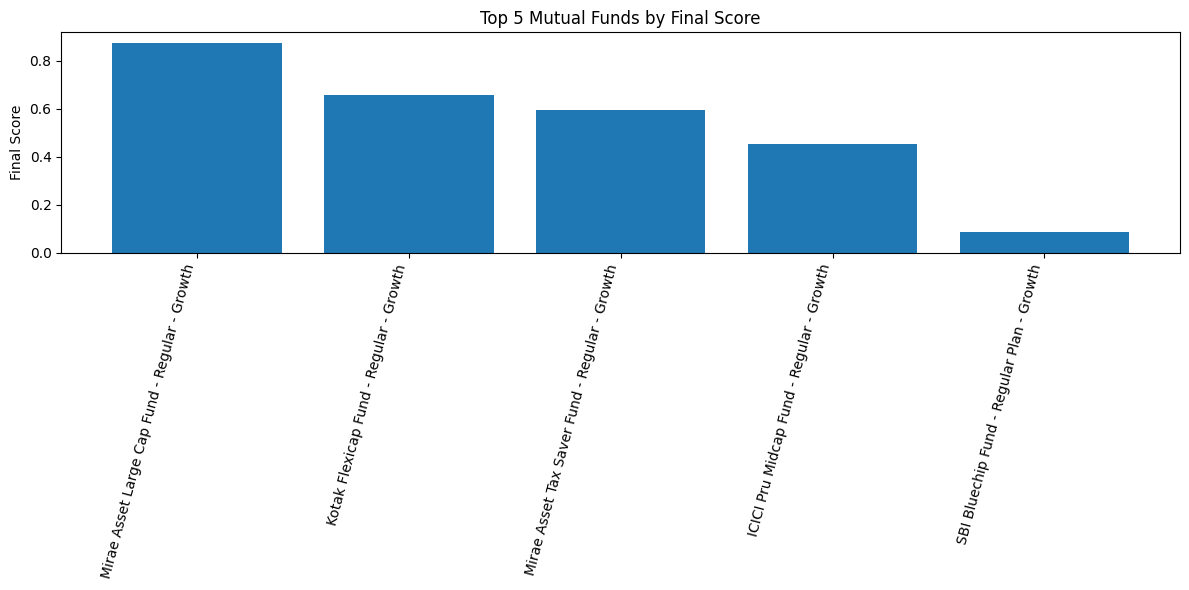

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top5["scheme_name"],
    top5["final_score"]
)

plt.xticks(rotation=75, ha="right")
plt.ylabel("Final Score")
plt.title("Top 5 Mutual Funds by Final Score")

plt.tight_layout()

plt.savefig("./charts/top5_funds_final_score.png")

plt.show()

In [24]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\final_mutual_fund_scorecard_updated.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [9]:
benchmark.head()

NameError: name 'benchmark' is not defined

In [27]:
'benchmark' in globals()

True

In [28]:
benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [29]:
[x for x in globals() if isinstance(globals()[x], pd.DataFrame)]

['_',
 '___',
 'benchmark',
 '_5',
 '_6',
 'nav',
 '_8',
 'df',
 '_10',
 'group',
 'tracking_error_df',
 '_12',
 '_13',
 'info_ratio_df',
 '_14',
 'scorecard',
 '_17',
 '_18',
 'top5',
 '_20',
 '_22',
 '_25',
 '_28']

In [30]:
benchmark.columns

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')

In [31]:
top5 = scorecard.nlargest(5, "final_score")

top5_codes = top5["amfi_code"].tolist()

top5[["scheme_name", "final_score"]]

,scheme_name,final_score
0,Mirae Asset Large Cap Fund - Regular - Growth,0.874814
1,Kotak Flexicap Fund - Regular - Growth,0.655633
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.593633
3,ICICI Pru Midcap Fund - Regular - Growth,0.452224
4,SBI Bluechip Fund - Regular Plan - Growth,0.083937


In [32]:
nav["date"] = pd.to_datetime(nav["date"])

top5_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

top5_nav = top5_nav.sort_values(["amfi_code", "date"])

top5_nav["fund_return"] = (
    top5_nav.groupby("amfi_code")["nav"].pct_change()
)

In [33]:
top5_nav = top5_nav.merge(
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="left"
)

top5_nav.head()

,amfi_code,date,nav,fund_return,benchmark_return
0,119551,2022-01-03,54.3856,NaN,NaN
1,119551,2022-01-03,54.3856,NaN,NaN
2,119551,2022-01-03,54.3856,NaN,NaN
3,119551,2022-01-03,54.3856,NaN,NaN
4,119551,2022-01-03,54.3856,NaN,NaN


In [6]:
top5_nav.columns

NameError: name 'top5_nav' is not defined

In [7]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    fund = top5_nav[top5_nav["amfi_code"] == code].copy()

    # Normalize NAV to ₹1 invested
    fund["growth"] = fund["nav"] / fund["nav"].iloc[0]

    scheme = top5.loc[
        top5["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        fund["date"],
        fund["growth"],
        label=scheme
    )

# Benchmark normalized to ₹1 invested
benchmark_plot = benchmark.copy()
benchmark_plot = benchmark_plot.sort_values("date")

benchmark_plot["growth"] = (
    benchmark_plot["close_value"] /
    benchmark_plot["close_value"].iloc[0]
)

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["growth"],
    color="black",
    linewidth=3,
    linestyle="--",
    label="Benchmark"
)

plt.title("Top 5 Mutual Funds vs Benchmark (Growth of ₹1 Invested)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()

plt.savefig("charts/benchmark_comparison.png", dpi=300)

plt.show()

NameError: name 'plt' is not defined

In [5]:
benchmark["index_name"].unique()

NameError: name 'benchmark' is not defined

In [42]:
benchmark_plot = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_plot = benchmark_plot.sort_values("date")

benchmark_plot["growth"] = (
    benchmark_plot["close_value"] /
    benchmark_plot["close_value"].iloc[0]
)

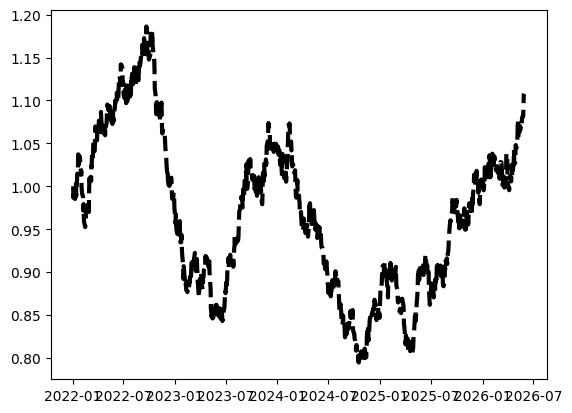

In [43]:
plt.plot(
    benchmark_plot["date"],
    benchmark_plot["growth"],
    color="black",
    linewidth=3,
    linestyle="--",
    label="Benchmark"
)

In [4]:
plt.tight_layout()

plt.savefig("charts/benchmark_comparison.png", dpi=300)

plt.show()

NameError: name 'plt' is not defined

In [12]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\final_mutual_fund_scorecard_updated.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [14]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\final_mutual_fund_scorecard_updated.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [13]:
import os

for file in os.listdir("."):
    if file.endswith(".csv"):
        print(file)

final_mutual_fund_ranking.csv
final_mutual_fund_scorecard.csv
final_mutual_fund_scorecard_updated.csv


In [15]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\final_mutual_fund_scorecard_updated.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv


In [16]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

.\final_mutual_fund_ranking.csv
.\final_mutual_fund_scorecard.csv
.\final_mutual_fund_scorecard_updated.csv
.\charts\alpha_beta_results.csv
.\charts\cagr_comparison.csv
.\charts\sharpe_ratio_results.csv
.\charts\sortino_ratio_results.csv
